# Experimento A/B — Impacto del pipeline de preprocesamiento

**Modelo A** — keypoints crudos, sin normalización, sin aumento (baseline)  
**Modelo B** — keypoints normalizados + 5 técnicas de aumento (pipeline completo)

**Metodología:**
- Split fijo (seed=42, estratificado) creado en la primera ejecución y reutilizado.
- Test set exportado a CSV para anotar en CVAT y ELAN.
- Misma arquitectura LSTM para A y B; único factor que cambia es el preprocesamiento.

**Justificación:** La mejora accuracy B > A cuantifica directamente el valor del pipeline (objetivo 2 de la tesis).

**Prerequisito:** `07_extraer_keypoints.py` ejecutado.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import (N_FRAMES, N_KEYPOINTS, DATA_DIR,
                           SPLIT_PATH, CSV_TOP35, KEYPOINTS_DIR)
from utils.preprocessing import normalizar_hombros
from utils.augmentation import aumentar_secuencia
from utils.model import construir_lstm, callbacks_entrenamiento
from utils.data_io import cargar_o_crear_split

SALIDA_DIR = os.path.join(DATA_DIR, "experimentos", "exp1_ab", "salidas")
os.makedirs(SALIDA_DIR, exist_ok=True)

BATCH_A, BATCH_B = 8, 16
MAX_EPOCHS       = 150
print(f"Directorio de salida: {SALIDA_DIR}")

## Carga del dataset top-35

In [2]:
def cargar_top35():
    df      = pd.read_csv(CSV_TOP35)
    clases  = sorted(df['glosa'].unique())
    idx_map = {c: i for i, c in enumerate(clases)}
    X, y, ids = [], [], []
    for _, row in df.iterrows():
        npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
        if not os.path.exists(npy): continue
        kp = np.load(npy)
        if kp.shape != (N_FRAMES, N_KEYPOINTS): continue
        X.append(kp); y.append(idx_map[row['glosa']]); ids.append(row['video_id'])
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.int32),
            ids, clases, idx_map, df)

X_all, y_all, video_ids, clases, idx_map, df_top35 = cargar_top35()
n_clases = len(clases)
print(f"Dataset top35: {len(X_all)} videos | {n_clases} clases")
print(f"Clases: {clases}")

Dataset top35: 153 videos | 35 clases
Clases: ['ABAJO_2', 'ACCIDENTE', 'ACOMODAR', 'AH,CLARO', 'ALGUNO', 'APROBAR', 'AUDIENCIA', 'AUDIOLOGÍA+AGENTE', 'AVERGONZAR', 'AVISO', 'BALONCESTO', 'BORRAR', 'BOTE', 'CORRECTO', 'CRECER', 'CUALQUIER', 'CUATRO DÓLARES', 'CULTURA', 'DEJAR', 'EL AÑO PASADO', 'ELEGANTE', 'ENCENDIDO', 'ENOJADO', 'ESCUCHAR', 'ESCUCHAR+(1h)RUMBLE', 'FAMOSO', 'FUEGOS ARTIFICIALES', 'FÓSFORO', 'GUITARRA', 'HIJA', 'JEFE', 'MIL', 'MOTIVAR', 'MUDARSE', 'PASTEL']


## Crear / cargar split fijo

In [3]:
idx_train, idx_val, idx_test = cargar_o_crear_split(SPLIT_PATH, y_all)
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# Exportar test set para anotar en CVAT y ELAN (una sola vez)
test_csv = os.path.join(SALIDA_DIR, 'videos_test_para_cvat_elan.csv')
if not os.path.exists(test_csv):
    df_test = df_top35.iloc[idx_test].copy()
    df_test['indice_en_dataset'] = idx_test
    cols = [c for c in ['video_id', 'glosa', 'video_path', 'tiempo_inicio',
                         'tiempo_fin', 'duracion_seg_etiqueta', 'indice_en_dataset']
            if c in df_test.columns]
    df_test[cols].to_csv(test_csv, index=False, encoding='utf-8-sig')
    print(f"Test set exportado: {test_csv}")
else:
    print(f"Test set ya existe: {test_csv}")

Split fijo cargado: train=83 | val=35 | test=35
Train: 83 | Val: 35 | Test: 35
Test set ya existe: C:\Users\dell\Documents\TIC\Codigo_TIC\experimento_ab\videos_test_para_cvat_elan.csv


## Función de entrenamiento

In [4]:
def entrenar(nombre, X_tr, y_tr, X_val, X_test, y_val, y_test, n_clases, batch):
    print(f"\n{'='*50}\nMODELO {nombre}  (train={len(X_tr)})\n{'='*50}")
    model = construir_lstm(n_clases, lr=0.001, dropout=0.5,
                            regularizacion=0.005, capa_densa=False)
    hist = model.fit(X_tr, to_categorical(y_tr, n_clases),
                     validation_data=(X_val, to_categorical(y_val, n_clases)),
                     epochs=MAX_EPOCHS, batch_size=batch,
                     callbacks=callbacks_entrenamiento(patience_stop=20, patience_lr=8),
                     verbose=1)
    pred      = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc       = accuracy_score(y_test, pred)
    hist_dict = hist.history
    acc_key = 'accuracy' if 'accuracy' in hist_dict else 'categorical_accuracy'
    epocas  = len(hist_dict[acc_key])
    print(f"\nModelo {nombre}: {acc*100:.1f}% | {epocas} épocas")
    return model, acc, epocas, pred, hist_dict

## Modelo A — sin preprocesamiento (baseline)

In [5]:
y_val_arr  = y_all[idx_val]
y_test_arr = y_all[idx_test]

model_A, acc_A, ep_A, pred_A, hist_A = entrenar(
    "A (sin preprocesamiento)",
    X_all[idx_train], y_all[idx_train],
    X_all[idx_val], X_all[idx_test],
    y_val_arr, y_test_arr, n_clases, BATCH_A)

model_A.save(os.path.join(SALIDA_DIR, 'modelo_A.h5'))
np.save(os.path.join(SALIDA_DIR, 'historial_A.npy'), hist_A)
print(f"Modelo A guardado — Accuracy: {acc_A*100:.1f}%")


MODELO A (sin preprocesamiento)  (train=83)


Epoch 1/150


 1/11 [=>............................] - ETA: 1:49 - loss: 5.4041 - accuracy: 0.0000e+00

 2/11 [====>.........................] - ETA: 0s - loss: 6.1206 - accuracy: 0.0000e+00  

 3/11 [=======>......................] - ETA: 0s - loss: 5.8050 - accuracy: 0.0417    

...

Restoring model weights from the end of the best epoch: 85.


11/11 [==============================] - 1s 63ms/step - loss: 2.5277 - accuracy: 0.6145 - val_loss: 3.7054 - val_accuracy: 0.2857 - lr: 3.1250e-05


Epoch 105: early stopping



Modelo A (sin preprocesamiento): 42.9% | 105 épocas
Modelo A guardado — Accuracy: 42.9%


C:\Users\dell\miniconda3\envs\senas_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Modelo B — normalizado + 5 técnicas de aumento

In [6]:
X_tr_B, y_tr_B = [], []
for i in idx_train:
    for v in aumentar_secuencia(normalizar_hombros(X_all[i])):
        X_tr_B.append(v); y_tr_B.append(y_all[i])
X_tr_B   = np.array(X_tr_B, dtype=np.float32)
y_tr_B   = np.array(y_tr_B, dtype=np.int32)
X_val_B  = np.array([normalizar_hombros(X_all[i]) for i in idx_val],  dtype=np.float32)
X_test_B = np.array([normalizar_hombros(X_all[i]) for i in idx_test], dtype=np.float32)

print(f"Train B aumentado: {len(X_tr_B)} muestras (x{len(X_tr_B)//len(idx_train)} factor)")

model_B, acc_B, ep_B, pred_B, hist_B = entrenar(
    "B (normalizado + aumentado)",
    X_tr_B, y_tr_B, X_val_B, X_test_B,
    y_val_arr, y_test_arr, n_clases, BATCH_B)

model_B.save(os.path.join(SALIDA_DIR, 'modelo_B.h5'))
np.save(os.path.join(SALIDA_DIR, 'historial_B.npy'), hist_B)
print(f"Modelo B guardado — Accuracy: {acc_B*100:.1f}%")

Train B aumentado: 498 muestras (x6 factor)

MODELO B (normalizado + aumentado)  (train=498)


Epoch 1/150


 1/32 [..............................] - ETA: 5:23 - loss: 5.7770 - accuracy: 0.0625

 2/32 [>.............................] - ETA: 1s - loss: 6.1414 - accuracy: 0.0312  

 3/32 [=>............................] - ETA: 1s - loss: 5.9087 - accuracy: 0.0208

...

Restoring model weights from the end of the best epoch: 21.


32/32 [==============================] - 2s 56ms/step - loss: 1.3185 - accuracy: 0.8213 - val_loss: 3.6997 - val_accuracy: 0.3429 - lr: 2.5000e-04


Epoch 41: early stopping



Modelo B (normalizado + aumentado): 42.9% | 41 épocas
Modelo B guardado — Accuracy: 42.9%


C:\Users\dell\miniconda3\envs\senas_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Comparativa final A vs B

In [7]:
print(f"\n{'='*50}\nCOMPARATIVA A vs B\n{'='*50}")
print(f"  A (sin preprocesamiento): {acc_A*100:.1f}%  ({len(idx_train)} muestras train)")
print(f"  B (pipeline completo):    {acc_B*100:.1f}%  ({len(X_tr_B)} muestras train)")
print(f"  Mejora pipeline:          {(acc_B - acc_A)*100:+.1f} pp")

print(f"\nReporte por seña — Modelo B:")
print(classification_report(y_test_arr, pred_B, target_names=clases, zero_division=0))

df_comparativa = pd.DataFrame({
    'modelo':         ['A - sin preprocesamiento', 'B - pipeline completo'],
    'accuracy':       [acc_A, acc_B],
    'epocas':         [ep_A, ep_B],
    'muestras_train': [len(idx_train), len(X_tr_B)],
    'n_clases':       [n_clases, n_clases],
    'videos_test':    [len(idx_test), len(idx_test)],
})
ruta_csv = os.path.join(SALIDA_DIR, 'comparativa_ab.csv')
df_comparativa.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
print(f"\nResultados guardados en: {ruta_csv}")
df_comparativa


COMPARATIVA A vs B
  A (sin preprocesamiento): 42.9%  (83 muestras train)
  B (pipeline completo):    42.9%  (498 muestras train)
  Mejora pipeline:          +0.0 pp

Reporte por seña — Modelo B:
                     precision    recall  f1-score   support

            ABAJO_2       0.50      1.00      0.67         1
          ACCIDENTE       1.00      1.00      1.00         1
           ACOMODAR       0.33      1.00      0.50         1
           AH,CLARO       0.00      0.00      0.00         1
             ALGUNO       0.00      0.00      0.00         1
            APROBAR       1.00      1.00      1.00         1
          AUDIENCIA       0.50      1.00      0.67         1
  AUDIOLOGÍA+AGENTE       0.00      0.00      0.00         1
         AVERGONZAR       0.33      1.00      0.50         1
              AVISO       0.00      0.00      0.00         1
         BALONCESTO       0.00      0.00      0.00         1
             BORRAR       0.00      0.00      0.00         1
         

,modelo,accuracy,epocas,muestras_train,n_clases,videos_test
0,A - sin preprocesamiento,0.428571,105,83,35,35
1,B - pipeline completo,0.428571,41,498,35,35


## Visualización curvas de entrenamiento

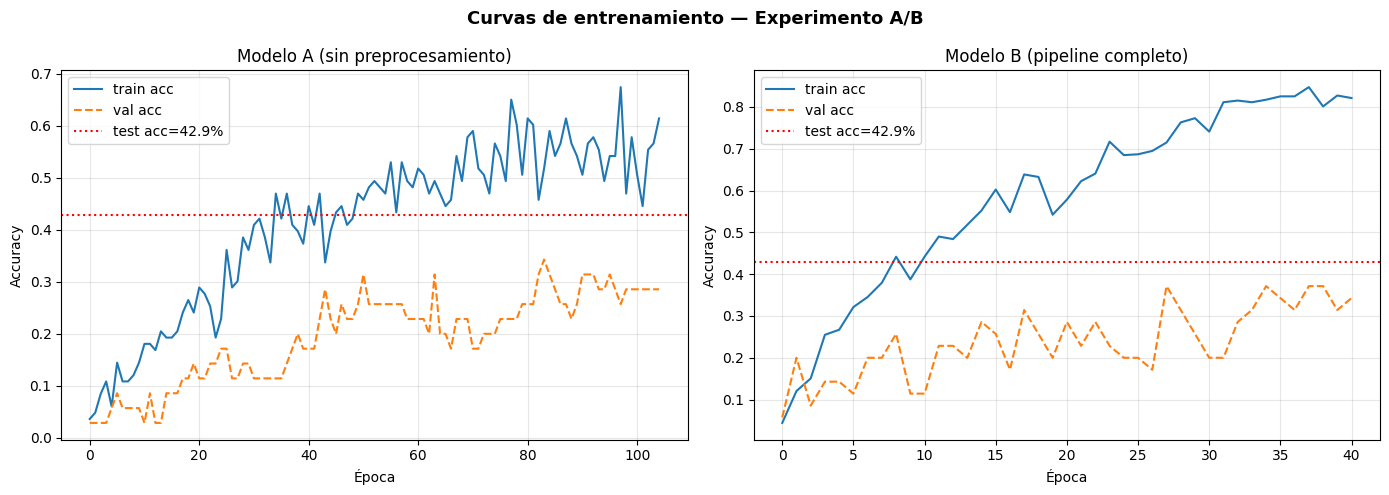

Figura guardada.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, nombre, acc in zip(
        axes,
        [hist_A, hist_B],
        ['A (sin preprocesamiento)', 'B (pipeline completo)'],
        [acc_A, acc_B]):
    acc_key = 'accuracy' if 'accuracy' in hist else 'categorical_accuracy'
    ax.plot(hist[acc_key],     label='train acc')
    ax.plot(hist['val_accuracy'], label='val acc',  linestyle='--')
    ax.axhline(acc, color='red', linestyle=':', label=f'test acc={acc*100:.1f}%')
    ax.set_title(f'Modelo {nombre}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Experimento A/B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'curvas_entrenamiento_ab.png'), dpi=150)
plt.show()
print("Figura guardada.")